In [2]:
import numpy as np
import matplotlib.pyplot as plt

from physics.schwarzschild import SMetric

plt.style.use('dark_background')

metric = SMetric()
print(f"Masa: {metric.M}")
print(f"Radio de Schwarzschild (r_s): {metric.r_s}")
print(f"Radio de Esfera de Fotones (r_photon): {metric.r_photon}")
print(f"Parámetro de Impacto Crítico (b_crit): {metric.b_crit:.4f}")

Masa: 1.0
Radio de Schwarzschild (r_s): 2.0
Radio de Esfera de Fotones (r_photon): 3.0
Parámetro de Impacto Crítico (b_crit): 5.1962


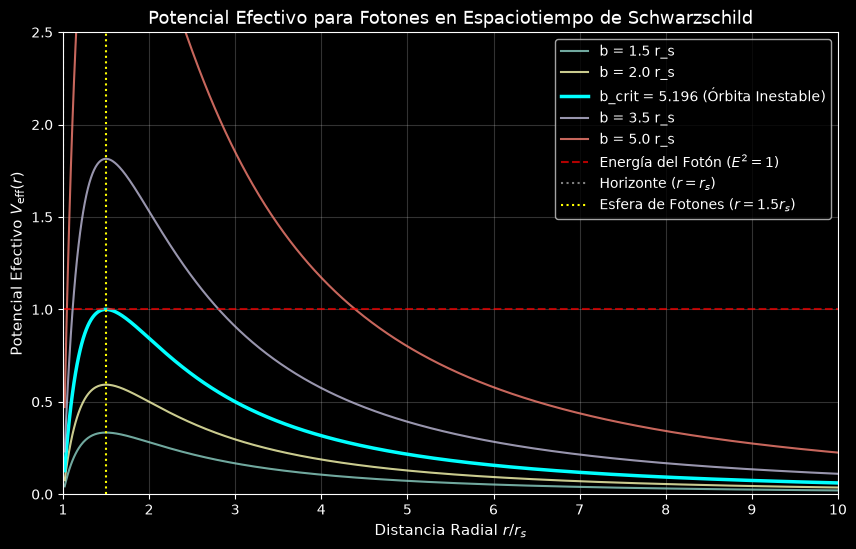

In [3]:
# Rango radial para graficar (desde justo fuera del horizonte hasta 10 r_s)
r = np.linspace(1.02 * metric.r_s, 10.0 * metric.r_s, 1000)

# Diferentes valores de b (en unidades de r_s)
b_factors = [1.5, 2.0, metric.b_crit / metric.r_s, 3.5, 5.0]

plt.figure(figsize=(10, 6))

for factor in b_factors:
    b_val = factor * metric.r_s
    v_eff = metric.V_eff(r, b_val)
    
    # Destacar la curva crítica b_crit
    if np.isclose(factor, metric.b_crit / metric.r_s):
        plt.plot(r / metric.r_s, v_eff, label=f"b_crit = {b_val:.3f} (Órbita Inestable)", color="cyan", linewidth=2.5)
    else:
        plt.plot(r / metric.r_s, v_eff, label=f"b = {factor:.1f} r_s", alpha=0.8)

# Línea de energía del fotón (E^2 = 1.0)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.7, label=r"Energía del Fotón ($E^2 = 1$)")

# Líneas verticales indicando radios clave
plt.axvline(metric.r_horizon / metric.r_s, color='gray', linestyle=':', label=r"Horizonte ($r = r_s$)")
plt.axvline(metric.r_photon / metric.r_s, color='yellow', linestyle=':', label=r"Esfera de Fotones ($r = 1.5 r_s$)")

# Configuración del gráfico
plt.title("Potencial Efectivo para Fotones en Espaciotiempo de Schwarzschild", fontsize=13)
plt.xlabel(r"Distancia Radial $r / r_s$", fontsize=11)
plt.ylabel(r"Potencial Efectivo $V_{\mathrm{eff}}(r)$", fontsize=11)
plt.ylim(0, 2.5)
plt.xlim(1.0, 10.0)
plt.legend(loc="upper right", framealpha=0.8)
plt.grid(True, alpha=0.2)
plt.show()

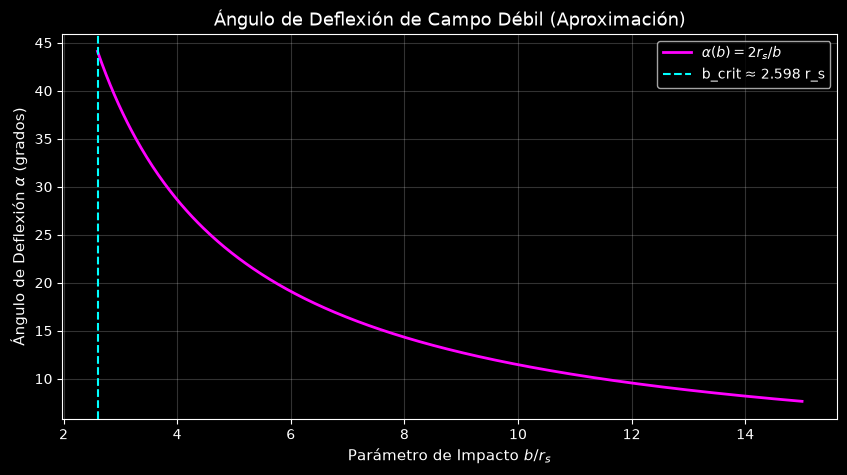

In [4]:
# Rango de parámetros de impacto desde b_crit hasta 15 r_s
b = np.linspace(metric.b_crit, 15.0 * metric.r_s, 500)
alpha_rad = metric.weak_field_deflection(b)
alpha_deg = np.degrees(alpha_rad)

plt.figure(figsize=(10, 5))
plt.plot(b / metric.r_s, alpha_deg, color='magenta', linewidth=2, label=r"$\alpha(b) = 2 r_s / b$")

# Marcar el límite crítico b_crit
plt.axvline(metric.b_crit / metric.r_s, color='cyan', linestyle='--', label=f"b_crit ≈ {metric.b_crit / metric.r_s:.3f} r_s")

plt.title("Ángulo de Deflexión de Campo Débil (Aproximación)", fontsize=13)
plt.xlabel(r"Parámetro de Impacto $b / r_s$", fontsize=11)
plt.ylabel(r"Ángulo de Deflexión $\alpha$ (grados)", fontsize=11)
plt.legend(loc="upper right", framealpha=0.8)
plt.grid(True, alpha=0.2)
plt.show()